In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load images
noise_img = cv2.imread("noise.jpg", cv2.IMREAD_GRAYSCALE)
sp_img1 = cv2.imread("salt&Pepper.jpg", cv2.IMREAD_GRAYSCALE)
sp_img2 = cv2.imread("salt&Pepper2.jpg", cv2.IMREAD_GRAYSCALE)

if noise_img is None:
    raise FileNotFoundError("Could not read noise.jpg")
if sp_img1 is None:
    raise FileNotFoundError("Could not read salt&Pepper.jpg")
if sp_img2 is None:
    raise FileNotFoundError("Could not read salt&Pepper2.jpg")

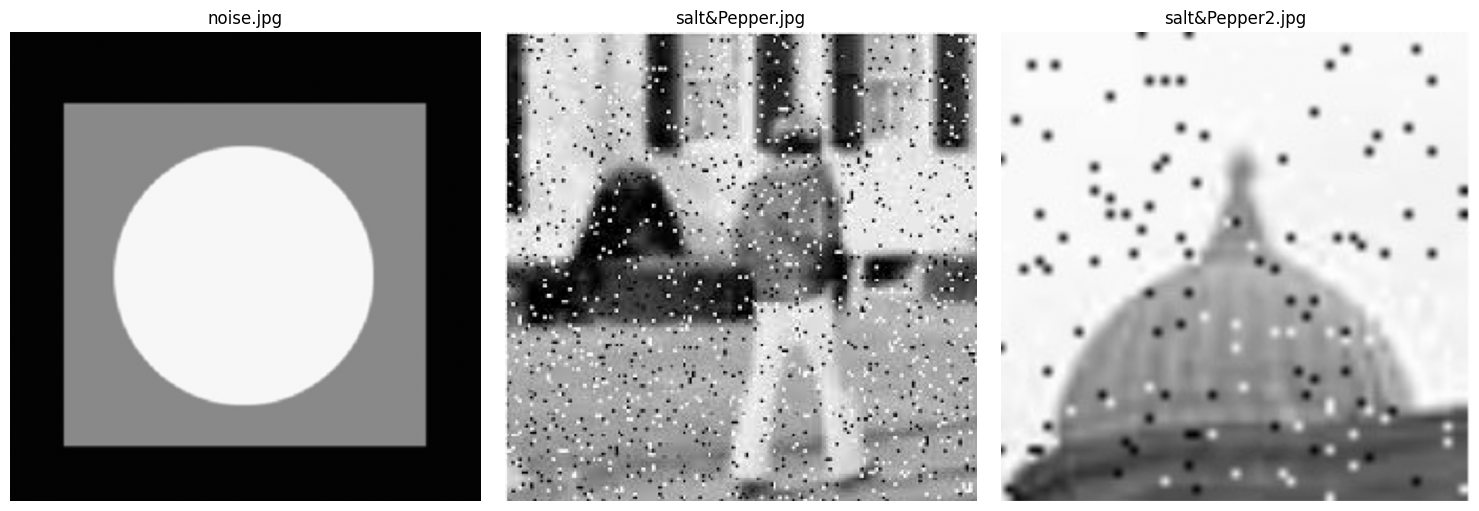

In [3]:
# Show original images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(noise_img, cmap="gray")
plt.title("noise.jpg")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sp_img1, cmap="gray")
plt.title("salt&Pepper.jpg")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sp_img2, cmap="gray")
plt.title("salt&Pepper2.jpg")
plt.axis("off")

plt.tight_layout()
plt.show()

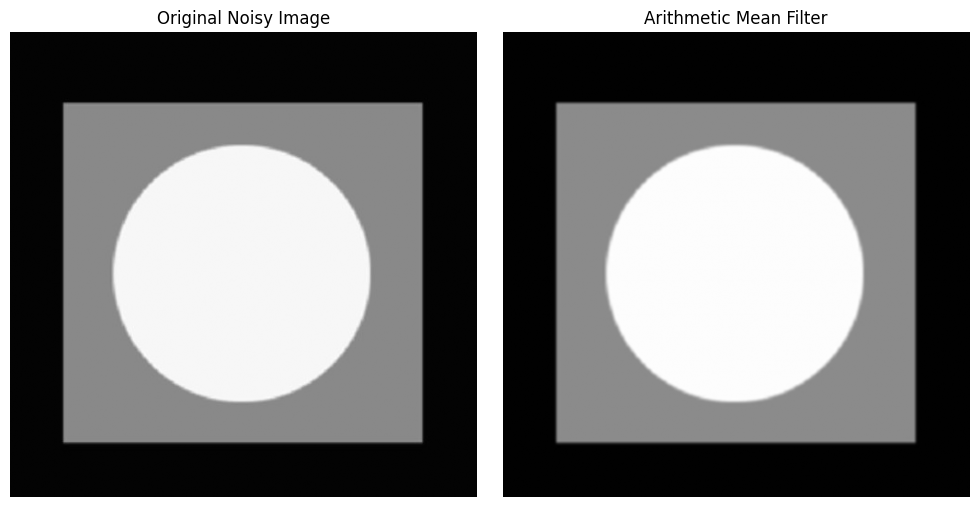

In [5]:
# Arithmetic Mean Filter using built-in blur
arith_builtin = cv2.blur(noise_img, (3, 3))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noise_img, cmap="gray")
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(arith_builtin, cmap="gray")
plt.title("Arithmetic Mean Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

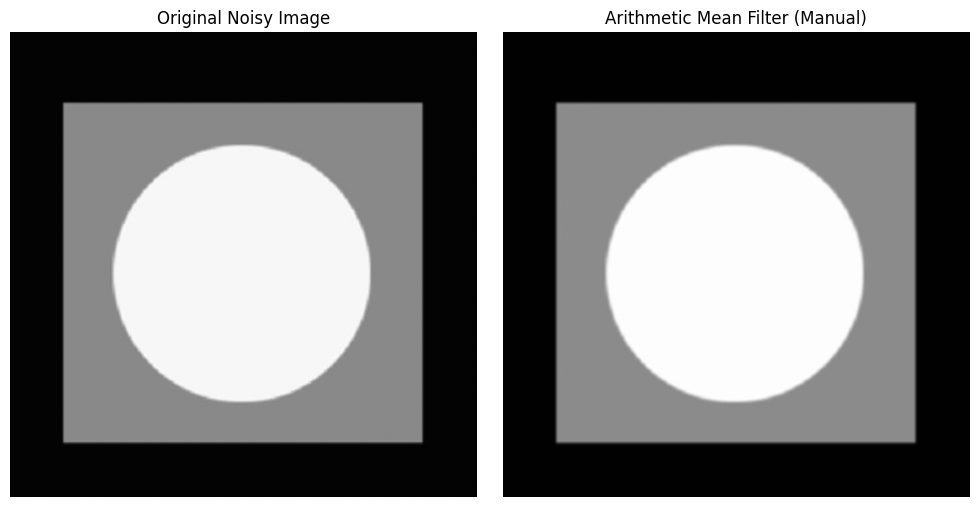

In [6]:
# Arithmetic Mean Filter manually
kernel = np.ones((3, 3), np.float32) / 9
arith_manual = cv2.filter2D(noise_img, -1, kernel)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noise_img, cmap="gray")
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(arith_manual, cmap="gray")
plt.title("Arithmetic Mean Filter (Manual)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
def geometric_mean_filter(image, kernel_size=3):
    img_float = image.astype(np.float64) + 1e-6
    log_img = np.log(img_float)

    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
    mean_log = cv2.filter2D(log_img, -1, kernel)

    geo_mean = np.exp(mean_log)
    return np.clip(geo_mean, 0, 255).astype(np.uint8)

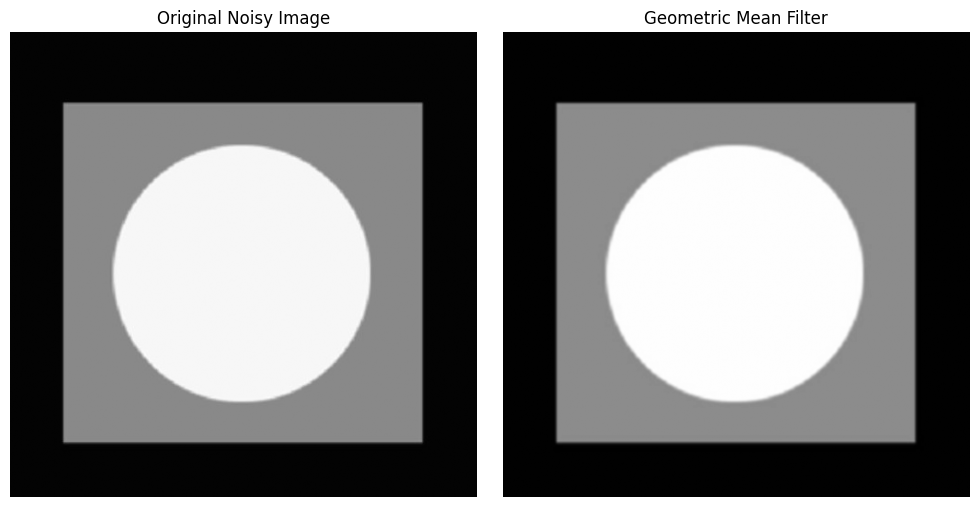

In [8]:
geo_result = geometric_mean_filter(noise_img, kernel_size=3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noise_img, cmap="gray")
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(geo_result, cmap="gray")
plt.title("Geometric Mean Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def harmonic_mean_filter(image, kernel_size=3):
    img_float = image.astype(np.float64) + 1e-6
    reciprocal_img = 1.0 / img_float

    kernel = np.ones((kernel_size, kernel_size), np.float32)
    sum_reciprocal = cv2.filter2D(reciprocal_img, -1, kernel)

    n = kernel_size * kernel_size
    harmonic_mean = n / sum_reciprocal

    return np.clip(harmonic_mean, 0, 255).astype(np.uint8)

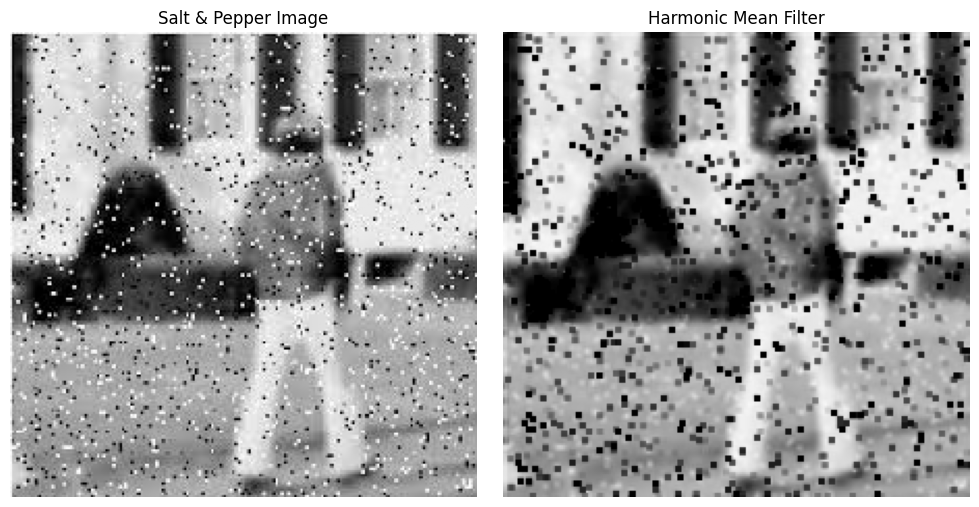

In [10]:
harmonic_result = harmonic_mean_filter(sp_img1, kernel_size=3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sp_img1, cmap="gray")
plt.title("Salt & Pepper Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(harmonic_result, cmap="gray")
plt.title("Harmonic Mean Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def contra_harmonic_mean(image, kernel_size=3, Q=0):
    img_float = image.astype(np.float64) + 1e-6

    numerator = np.power(img_float, Q + 1)
    denominator = np.power(img_float, Q)

    kernel = np.ones((kernel_size, kernel_size), np.float32)
    num_sum = cv2.filter2D(numerator, -1, kernel)
    den_sum = cv2.filter2D(denominator, -1, kernel)

    result = num_sum / (den_sum + 1e-6)
    return np.clip(result, 0, 255).astype(np.uint8)

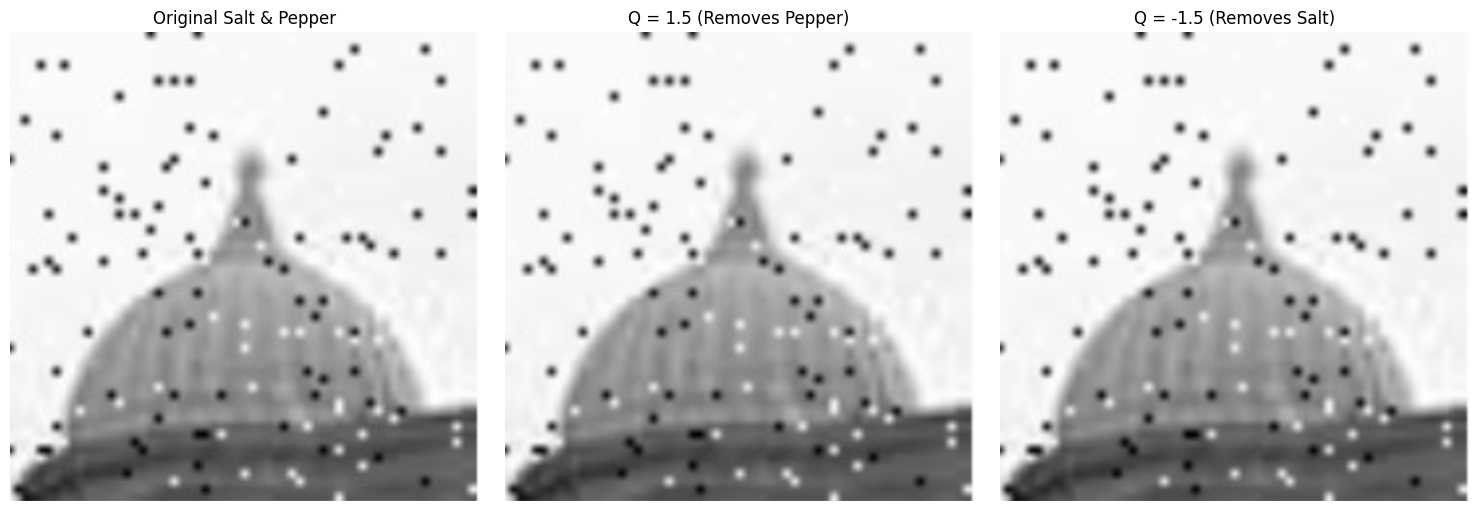

In [12]:
pepper_removed = contra_harmonic_mean(sp_img2, kernel_size=3, Q=1.5)
salt_removed = contra_harmonic_mean(sp_img2, kernel_size=3, Q=-1.5)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sp_img2, cmap="gray")
plt.title("Original Salt & Pepper")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pepper_removed, cmap="gray")
plt.title("Q = 1.5 (Removes Pepper)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(salt_removed, cmap="gray")
plt.title("Q = -1.5 (Removes Salt)")
plt.axis("off")

plt.tight_layout()
plt.show()

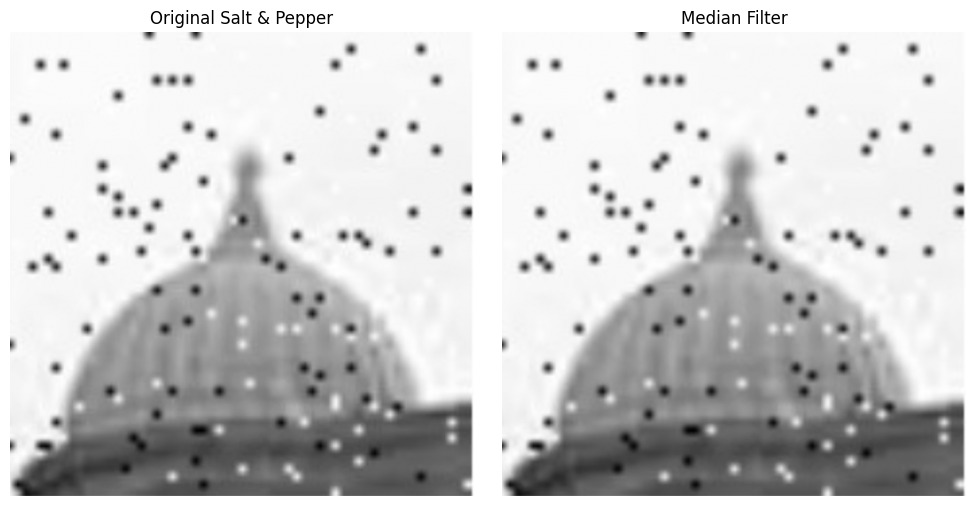

In [13]:
median_result = cv2.medianBlur(sp_img2, 3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sp_img2, cmap="gray")
plt.title("Original Salt & Pepper")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(median_result, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
kernel = np.ones((3, 3), np.uint8)

max_filter = cv2.dilate(sp_img2, kernel)
min_filter = cv2.erode(sp_img2, kernel)

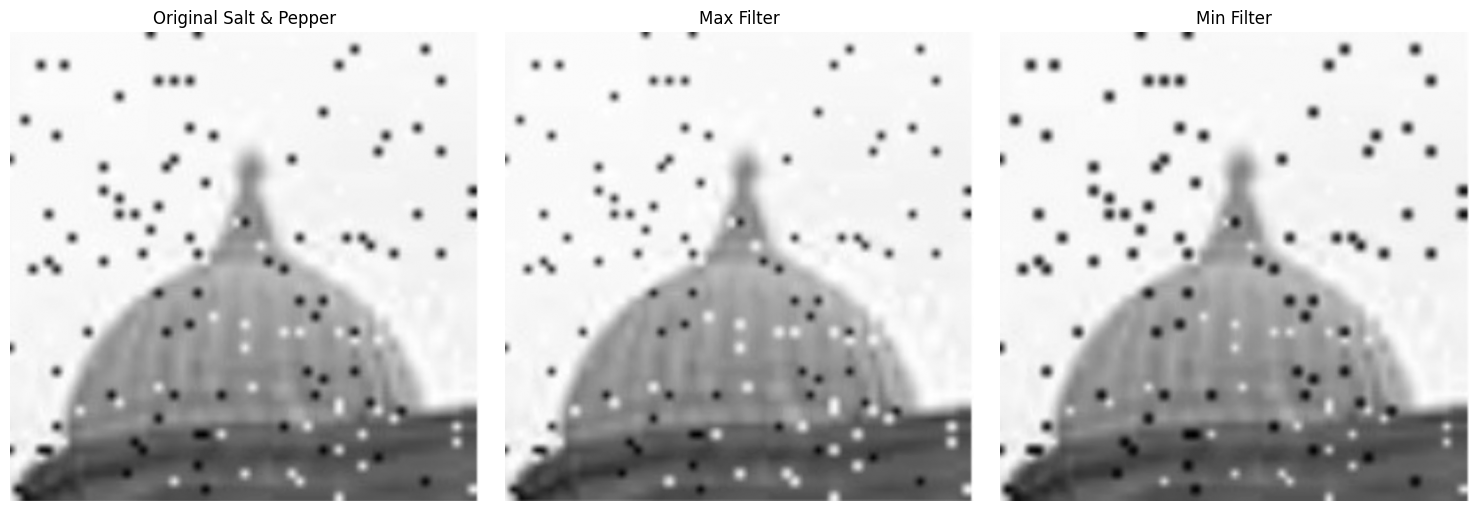

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sp_img2, cmap="gray")
plt.title("Original Salt & Pepper")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(max_filter, cmap="gray")
plt.title("Max Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(min_filter, cmap="gray")
plt.title("Min Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
def midpoint_filter(image, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    max_img = cv2.dilate(image, kernel).astype(np.float64)
    min_img = cv2.erode(image, kernel).astype(np.float64)

    midpoint = (max_img + min_img) / 2
    return midpoint.astype(np.uint8)

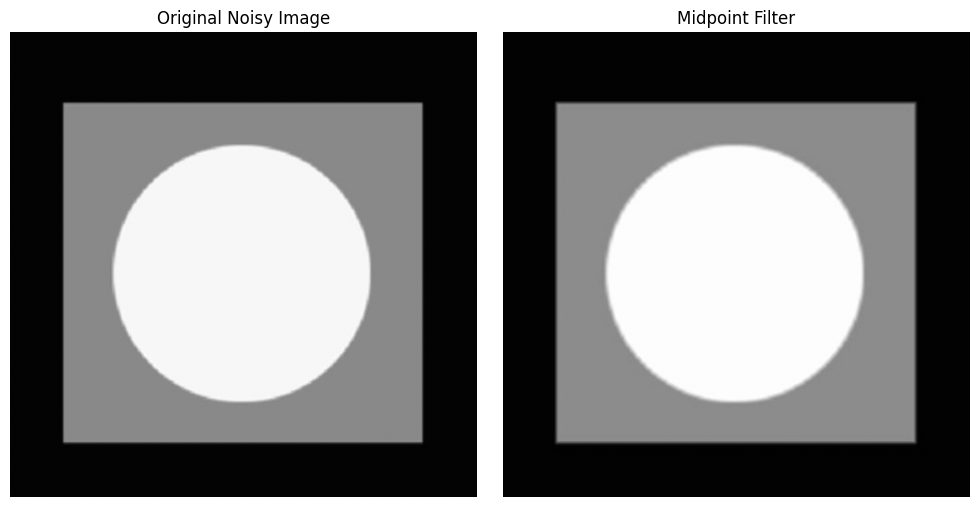

In [17]:
midpoint_result = midpoint_filter(noise_img, kernel_size=3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noise_img, cmap="gray")
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(midpoint_result, cmap="gray")
plt.title("Midpoint Filter")
plt.axis("off")

plt.tight_layout()
plt.show()